In [56]:
import os
import struct
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif

sns.set_theme(style='whitegrid')
DATA_DIR = os.path.join(os.getcwd(), 'datasets')

In [ ]:
import os
os.makedirs("figures", exist_ok=True)

def perform_eda(dataset_path, target_column=None):
    dataset_name = os.path.basename(dataset_path).split('.')[0].replace('_prediction_dataset', '').replace('_approval_dataset', '').lower()
    
    df = pd.read_csv(dataset_path) # pandas dataframe 
    df.columns = df.columns.str.strip()
    if target_column is None:
        target_column = df.columns[-1] # if no target column passed, last column is taken

    n_unique = df[target_column].nunique() # number of unique elements
    if df[target_column].dtype == 'object' or n_unique <= 20:
        problem_type = 'Binary Classification' if n_unique == 2 else 'Multi-class Classification'
    else:
        problem_type = 'Regression'

    print(f"Dataset   : {os.path.basename(dataset_path)}")
    print(f"Shape     : {df.shape}")
    print(f"Target    : {target_column}  |  Problem type: {problem_type}")
    print(f"Missing   : {df.isnull().sum().sum()} total missing values")
    print(f"Duplicates: {df.duplicated().sum()}")
    print()
    print("Data Types")
    print(df.dtypes)
    print()
    print("Summary Statistics ")
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    print(df[num_cols].describe())
    print()

    feat_cols = [c for c in num_cols if c != target_column] # feature columns

    # target distribution
    fig, ax = plt.subplots(figsize=(6, 4))
    if problem_type in ('Binary Classification', 'Multi-class Classification'):
        # bar plots for classification tasks 
        vc = df[target_column].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
        ax.set_title(f'Target Distribution: {target_column}')
        ax.set_xlabel(target_column); ax.set_ylabel('Count')
    else:
        # histograms for non classification tasks
        ax.hist(df[target_column].dropna(), bins=30, color='steelblue', edgecolor='white')
        ax.set_title(f'Target Distribution: {target_column}')
        ax.set_xlabel(target_column); ax.set_ylabel('Frequency')
    plt.tight_layout(); plt.savefig(f'figures/{dataset_name}_target_dist.eps', format='eps', dpi=600, bbox_inches='tight'); plt.show()
    # histograms
    if feat_cols:
        n = len(feat_cols); ncols = min(4, n); nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
        axes = np.array(axes).flatten()
        for i, col in enumerate(feat_cols):
            axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
            axes[i].set_title(col, fontsize=10)
        for j in range(i+1, len(axes)): axes[j].set_visible(False)
        plt.suptitle('Histograms', y=1.01); plt.tight_layout(); plt.savefig(f'figures/{dataset_name}_histograms.eps', format='eps', dpi=600, bbox_inches='tight'); plt.show()

    # box plots
    if feat_cols:
        
        n = len(feat_cols); ncols = min(4, n); nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
        axes = np.array(axes).flatten()
        for i, col in enumerate(feat_cols):
            if problem_type in ('Binary Classification', 'Multi-class Classification'):
                sns.boxplot(data=df, x=target_column, y=col, ax=axes[i], palette='Set2')
                axes[i].set_xlabel('Target Class')
            else:
                sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue')
                axes[i].set_xlabel('')
            axes[i].set_title(f'Boxplot: {col}', fontsize=10, fontweight='bold')
            axes[i].set_ylabel('Value')
            axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        for j in range(i+1, len(axes)): axes[j].set_visible(False)
        plt.suptitle('Outlier Detection & Feature Distribution (Box Plots)', y=1.02, fontsize=14, fontweight='bold')
        plt.tight_layout(); plt.savefig(f'figures/{dataset_name}_boxplots.eps', format='eps', dpi=600, bbox_inches='tight'); plt.show()

    # scatter plots (features vs target)
    if feat_cols and problem_type in ('Binary Classification', 'Multi-class Classification'):
        plot_cols = feat_cols[:4]
        n = len(plot_cols); ncols = min(4, n); nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
        axes = np.array(axes).flatten()
        for i, col in enumerate(plot_cols):
            for lbl in df[target_column].unique():
                mask = df[target_column] == lbl #boolean masking 
                axes[i].scatter(df.loc[mask, col], [str(lbl)] * mask.sum(), rasterized=True,
                                alpha=0.4, s=10, label=str(lbl))
            axes[i].set_title(col, fontsize=10); axes[i].set_xlabel(col)
        for j in range(i+1, len(axes)): axes[j].set_visible(False)
        plt.suptitle(f'Scatter Plots – Features vs {target_column}', y=1.01)
        plt.tight_layout(); plt.savefig(f'figures/{dataset_name}_scatter.eps', format='eps', dpi=600, bbox_inches='tight'); plt.show()

    # correlation heatmap (pearson correlation)
    if len(num_cols) >= 2:
        fig, ax = plt.subplots(figsize=(max(6, len(num_cols)), max(5, len(num_cols)-1)))
        sns.heatmap(df[num_cols].corr(), rasterized=True, annot=True, fmt='.2f',
                    cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
        ax.set_title('Correlation Heatmap')
        plt.tight_layout(); plt.savefig(f'figures/{dataset_name}_correlation.eps', format='eps', dpi=600, bbox_inches='tight'); plt.show()

    return df, target_column, problem_type


Dataset   : Iris.csv
Shape     : (150, 6)
Target    : Species  |  Problem type: Multi-class Classification
Missing   : 0 total missing values
Duplicates: 0

Data Types
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Summary Statistics 
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4

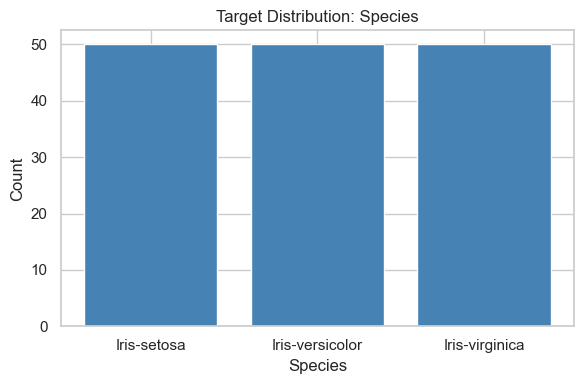

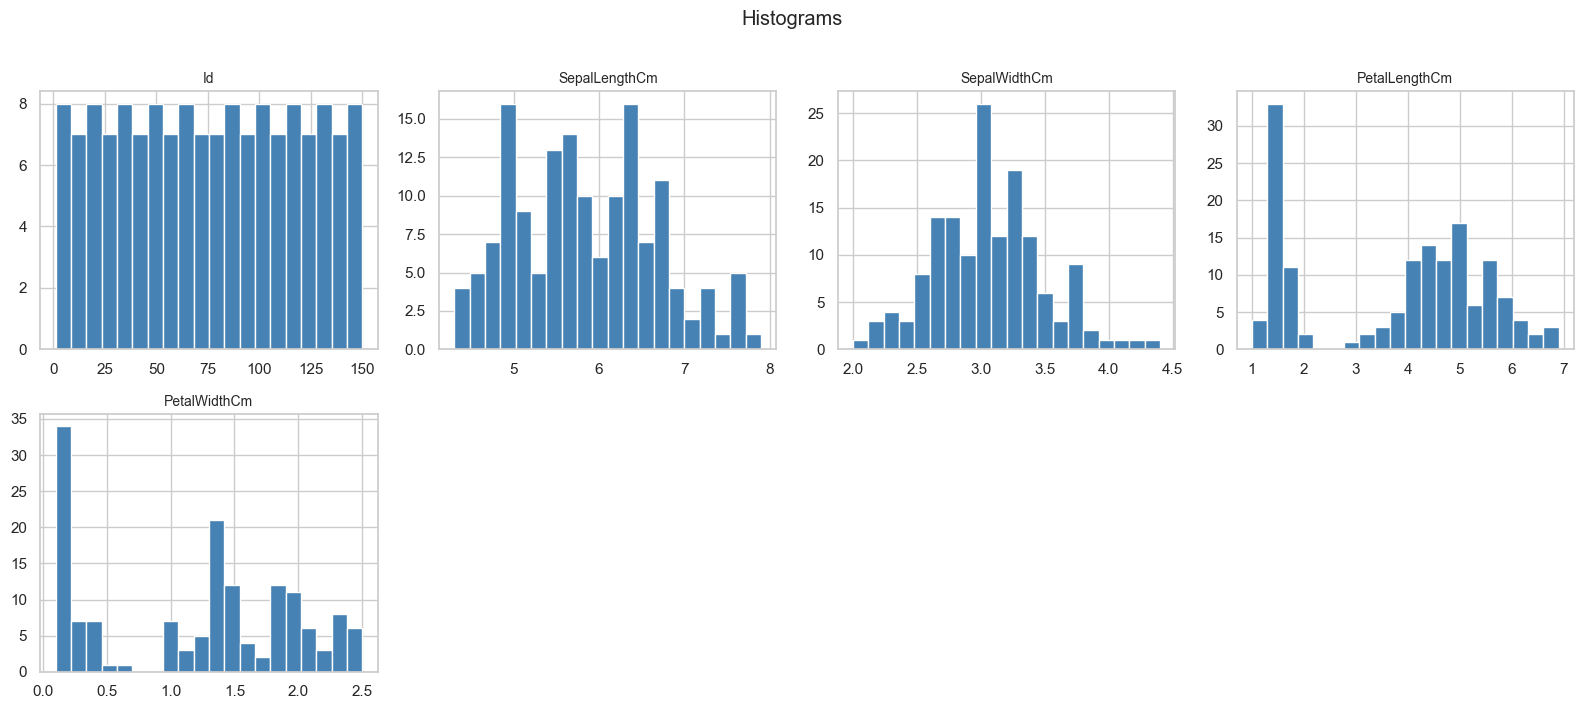

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


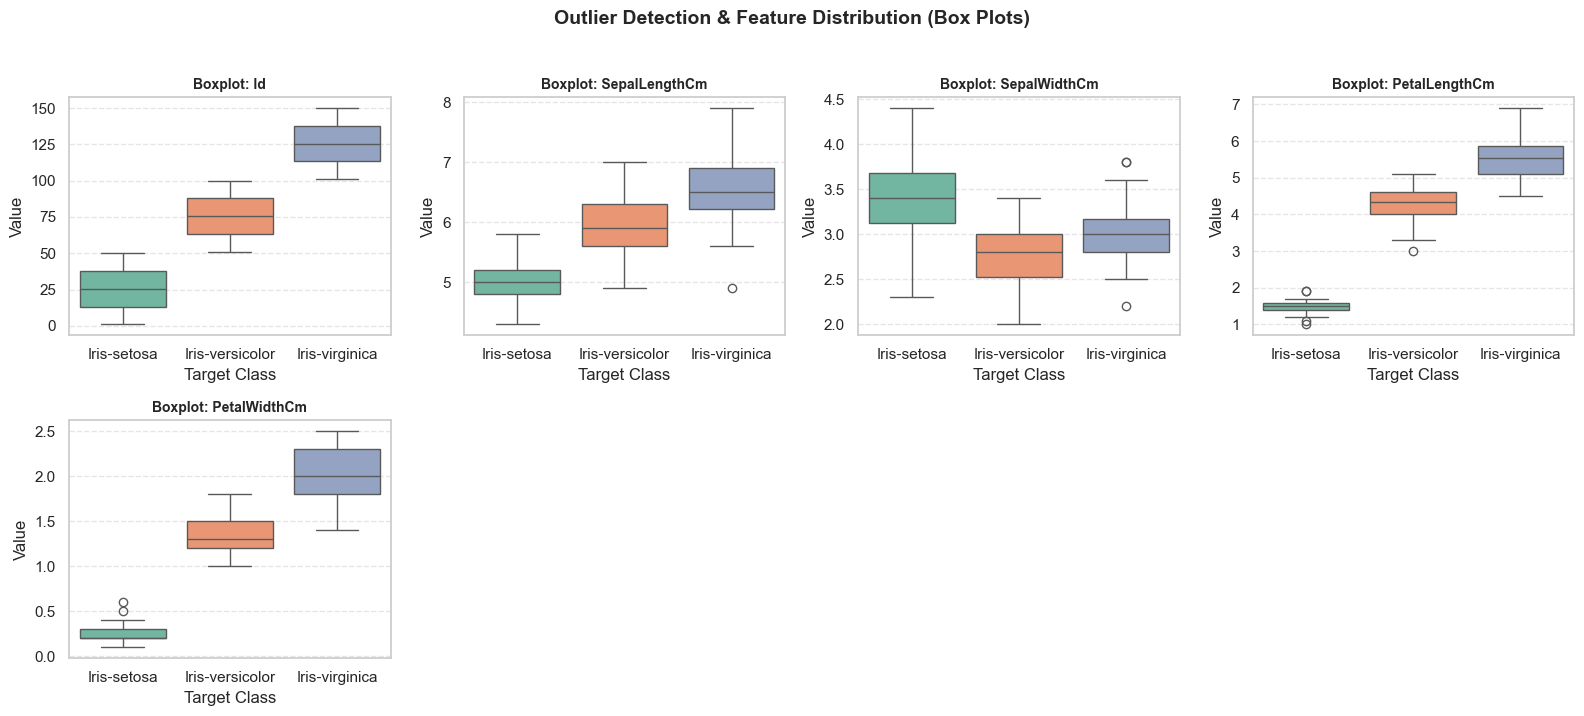

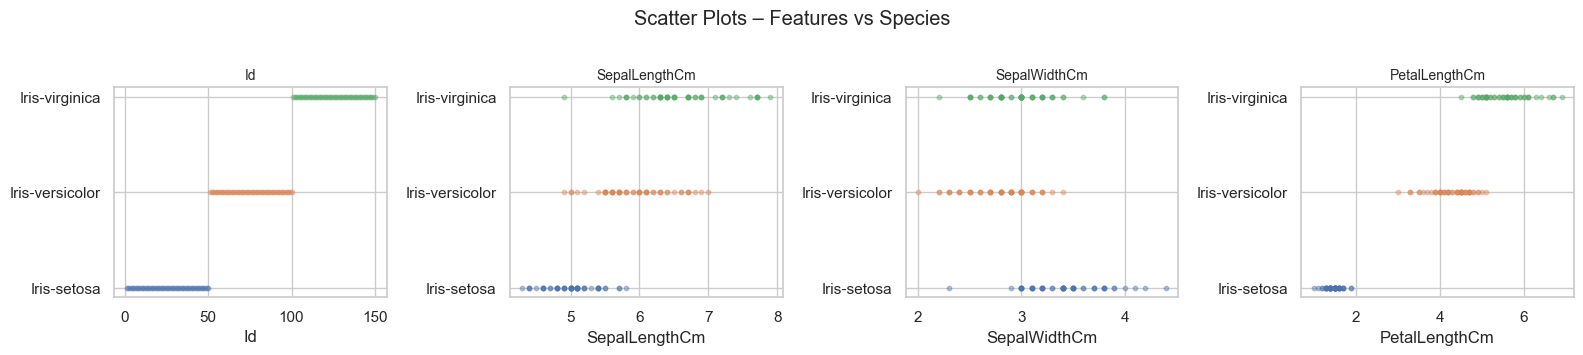

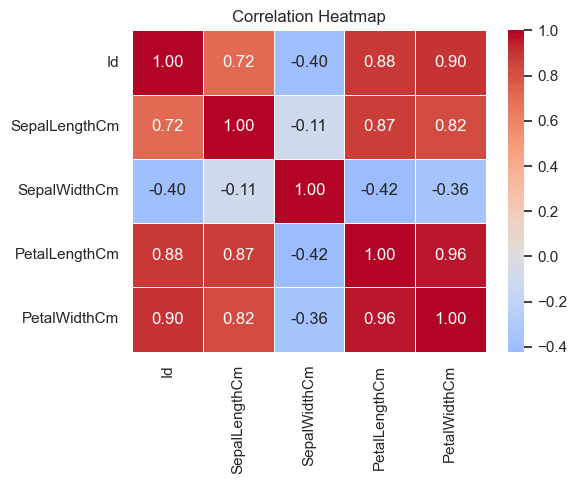

In [58]:
df_iris, target, ptype = perform_eda(os.path.join(DATA_DIR, 'Iris.csv'), target_column='Species')

Top 3 features (ANOVA): ['SepalLengthCm', 'PetalLengthCm', 'PetalWidthCm']


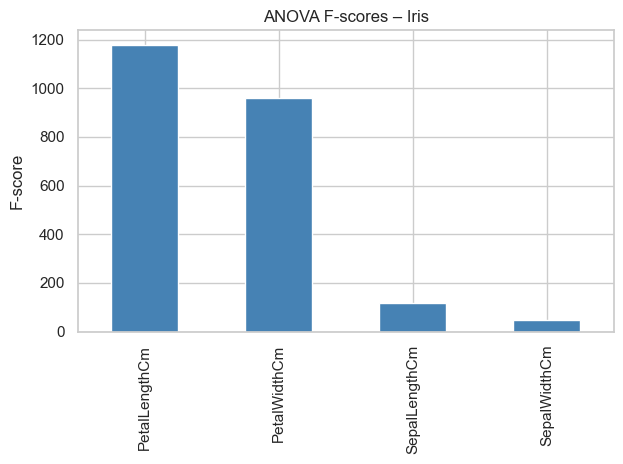

Train size: 120  |  Test size: 30


In [ ]:
#  preprocessing
df_iris.drop(columns=['Id'], inplace=True) # dropped id column

X = df_iris.drop(columns=['Species']) # storing column species separately
y = LabelEncoder().fit_transform(df_iris['Species']) # converting text based species into numeric values 

X_scaled = MinMaxScaler().fit_transform(X) # normalising so all values within [0,1]

# feature Selection(ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=3) # extracts 3 best from the array of relationship between x_scaled and y
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()].tolist()
print('Top 3 features (ANOVA):', selected_features)

# high F-score means that particular feature has strong univariate statistical discrimination based on anova criterion (variance between class/ variance within class) 
# feature importance scores
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False) # extracts computed F-score for the features and sorts them
scores.plot(kind='bar', color='steelblue', edgecolor='white', title='ANOVA F-scores – Iris')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Dataset   : diabetes_prediction_dataset.csv
Shape     : (100000, 9)
Target    : diabetes  |  Problem type: Binary Classification
Missing   : 0 total missing values
Duplicates: 3854

Data Types
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Summary Statistics 
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000

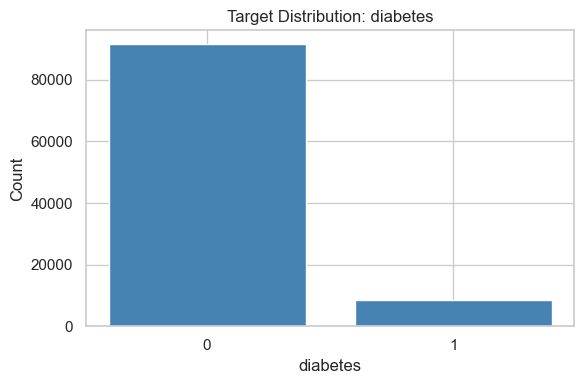

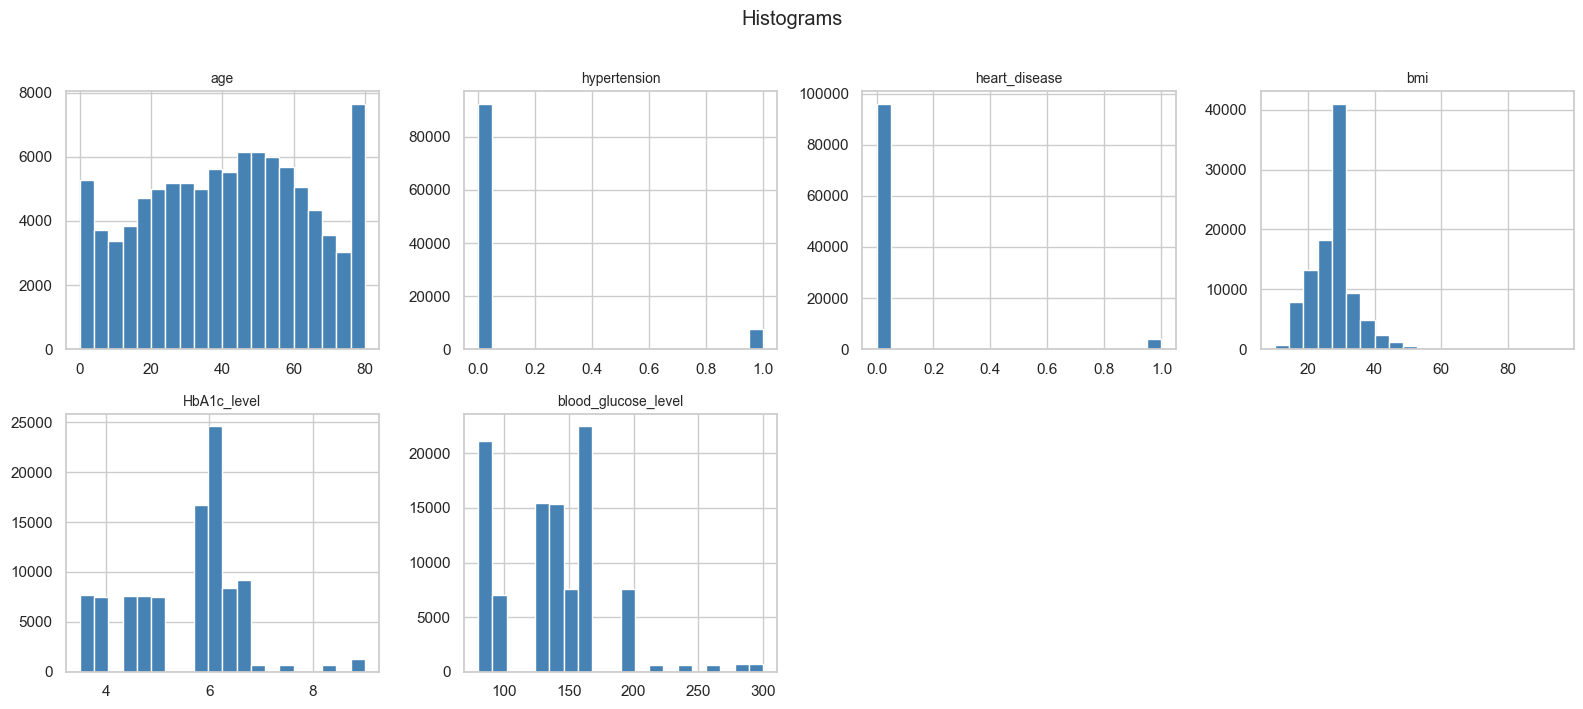

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


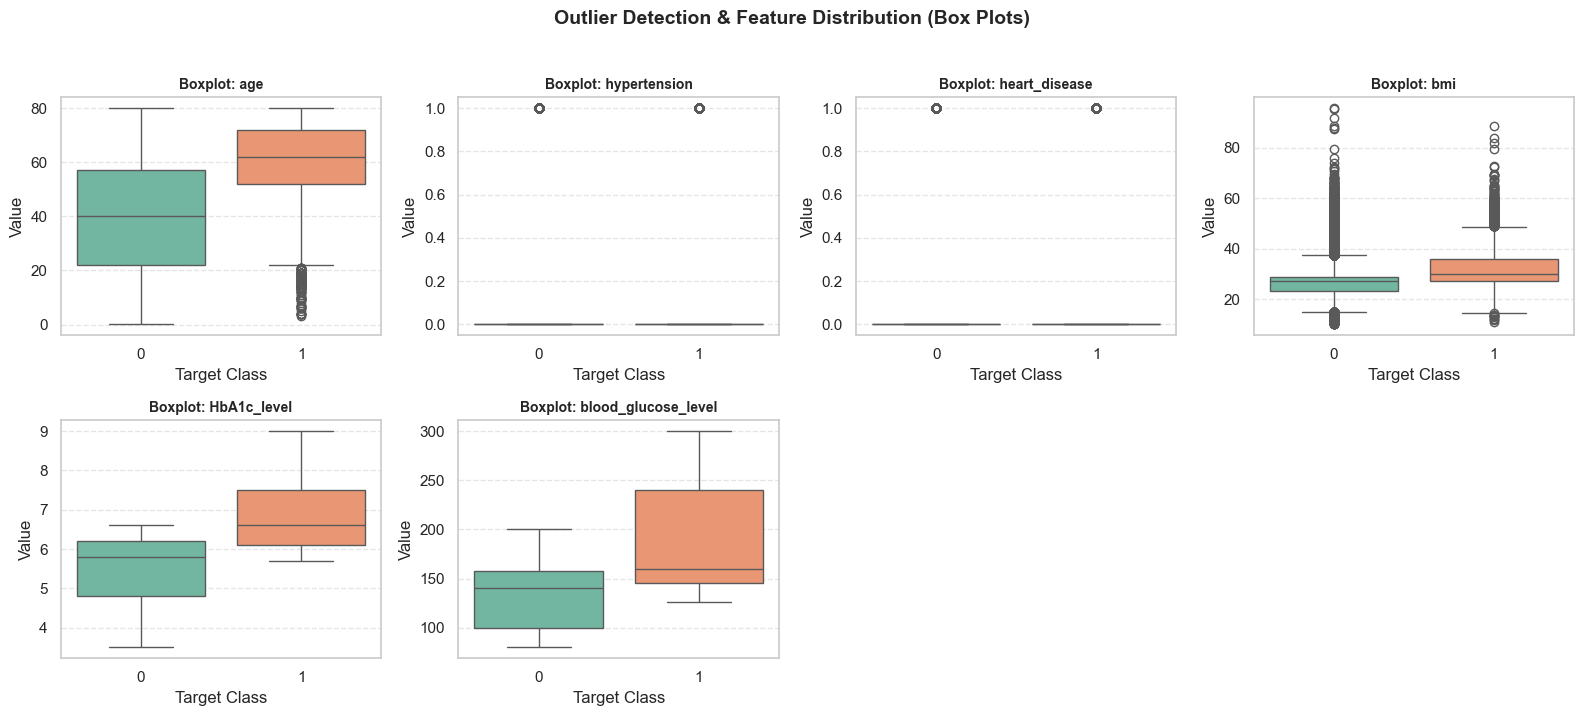

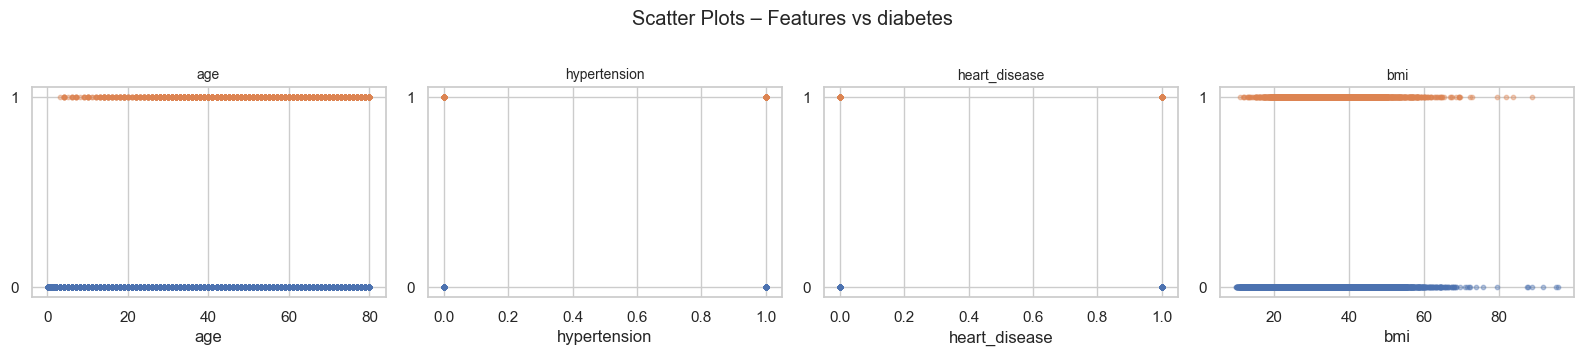

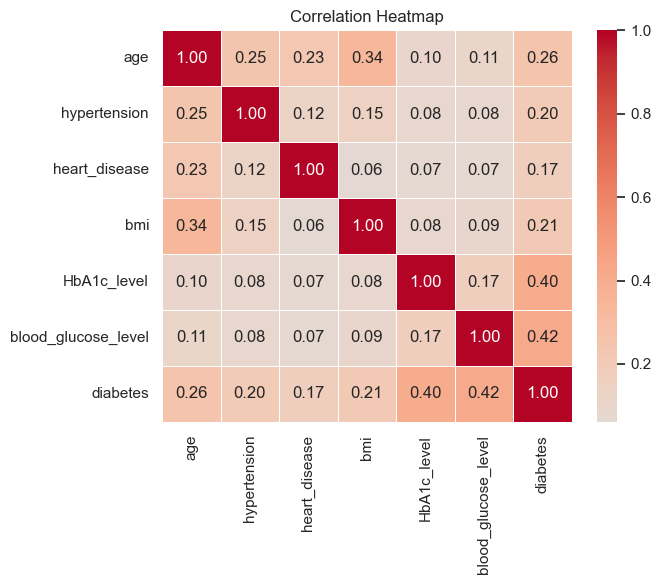

In [60]:
df_dia, target, ptype = perform_eda(
    os.path.join(DATA_DIR, 'diabetes_prediction_dataset.csv'),
    target_column='diabetes'
)

Top 5 features: ['age', 'hypertension', 'bmi', 'HbA1c_level', 'blood_glucose_level']


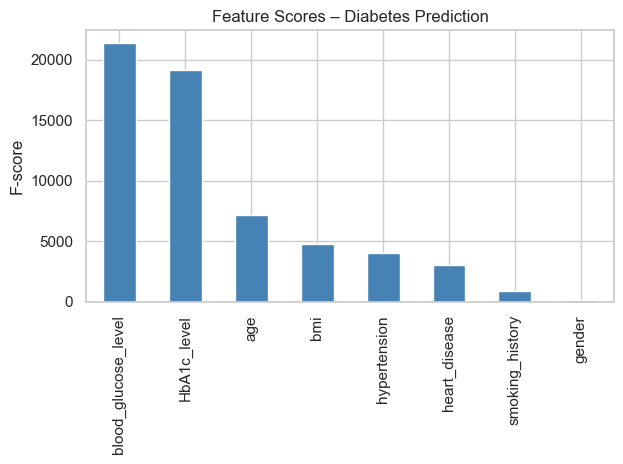

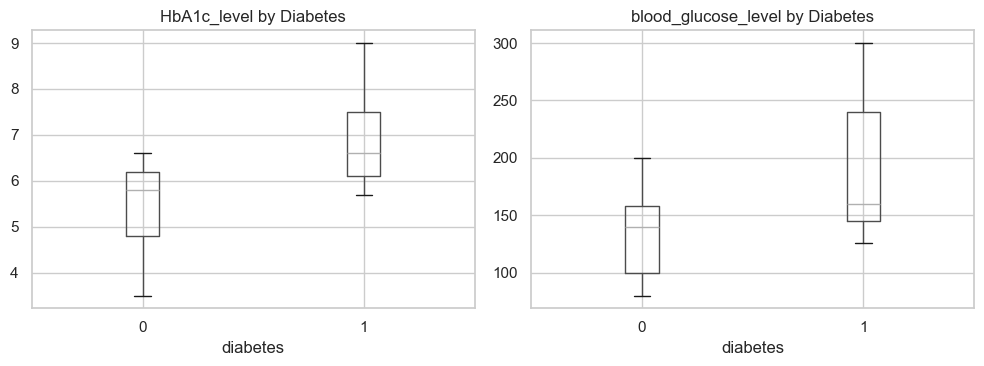

Train size: 80000  |  Test size: 20000


In [ ]:
df_dia = df_dia.copy()

# encoding categorical columns
le = LabelEncoder()
df_dia['gender'] = le.fit_transform(df_dia['gender'])
df_dia['smoking_history'] = le.fit_transform(df_dia['smoking_history'])

X = df_dia.drop(columns=['diabetes'])
y = df_dia['diabetes'] # target column
X_scaled = StandardScaler().fit_transform(X) # standard scaler ensures mean is 0 and sd is 1

# Feature Selection
# Chi square can only work with non-negative values but standardScaler may cause negative z-scores
# so ended up using ANOVA F-score
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()].tolist()
print('Top 5 features:', selected_features)

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
scores.plot(kind='bar', color='steelblue', edgecolor='white',
            title='Feature Scores – Diabetes Prediction')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

# box plot: key features vs diabetes label
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['HbA1c_level', 'blood_glucose_level']):
    df_dia.boxplot(column=col, by='diabetes', ax=ax)
    ax.set_title(f'{col} by Diabetes')
plt.suptitle('')
plt.tight_layout()
plt.show()

# stratify = y ensures the split is proportioned according to the original dataset
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2,
                                                     stratify=y, random_state=42)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Dataset   : loan_approval_dataset.csv
Shape     : (4269, 13)
Target    : loan_status  |  Problem type: Binary Classification
Missing   : 0 total missing values
Duplicates: 0

Data Types
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Summary Statistics 
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   


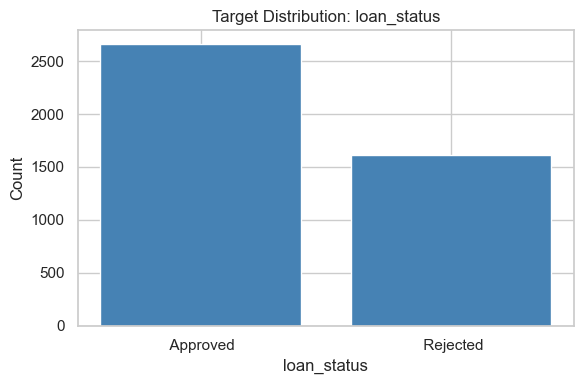

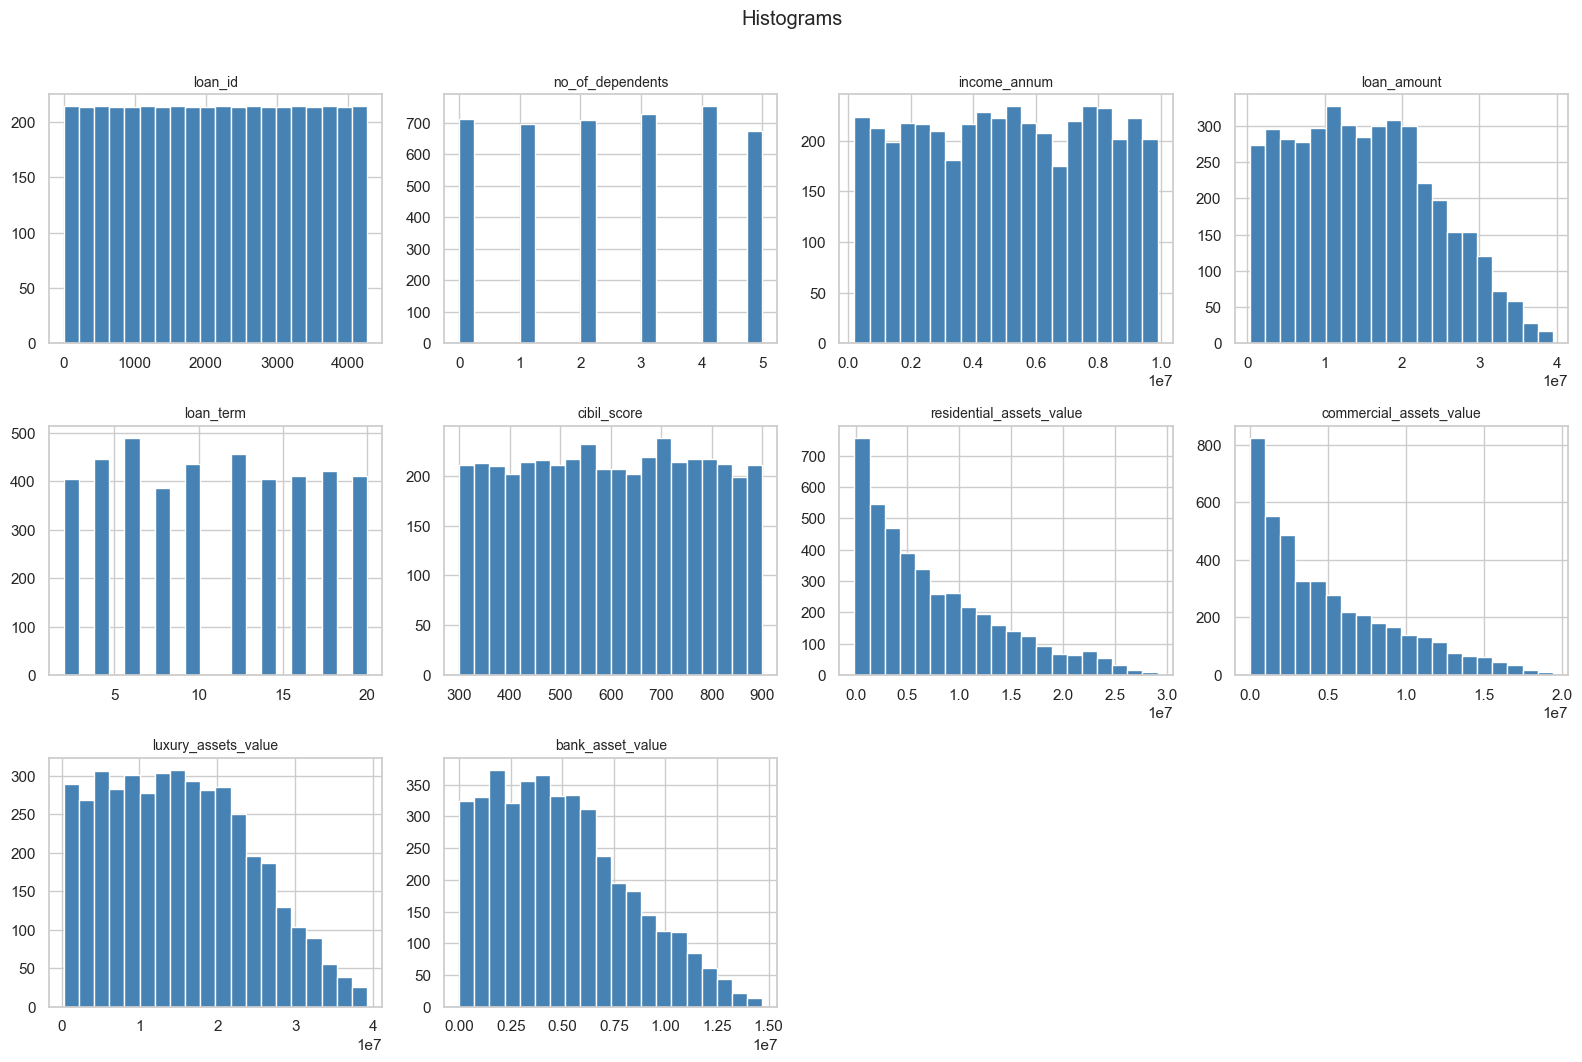

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


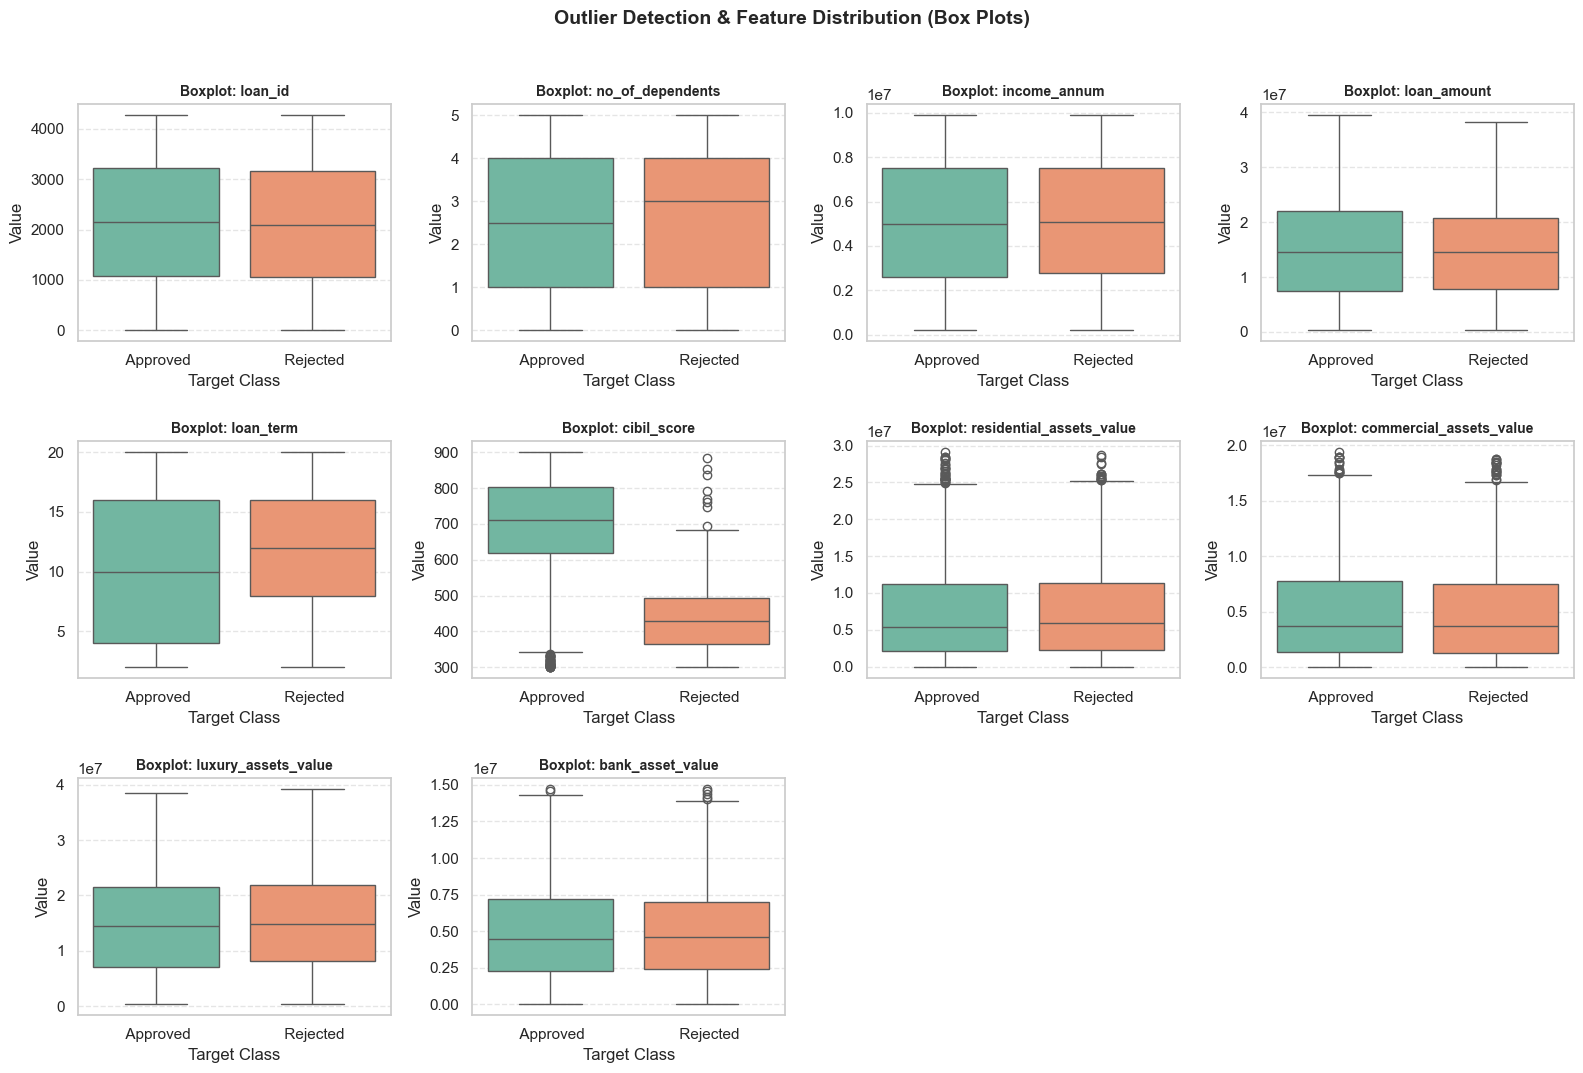

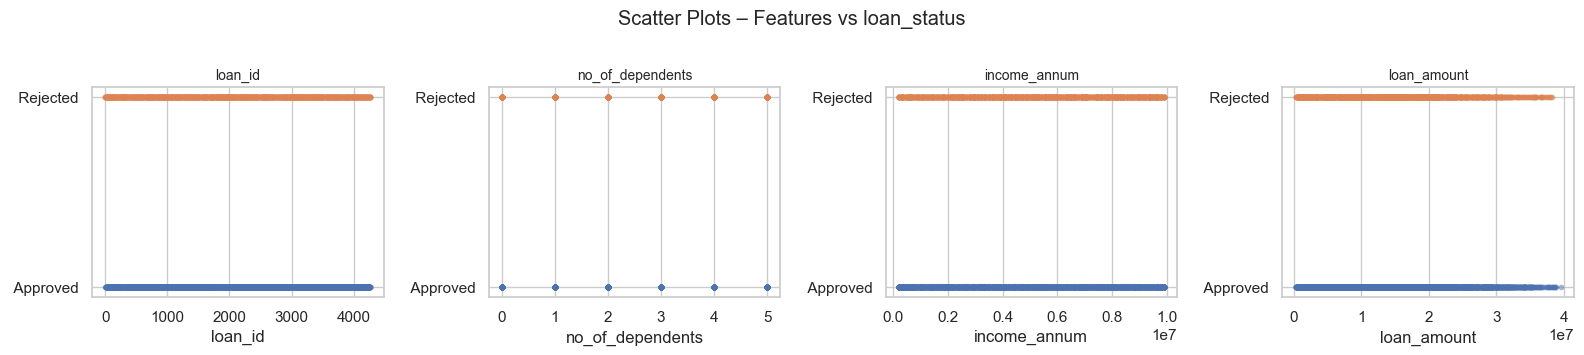

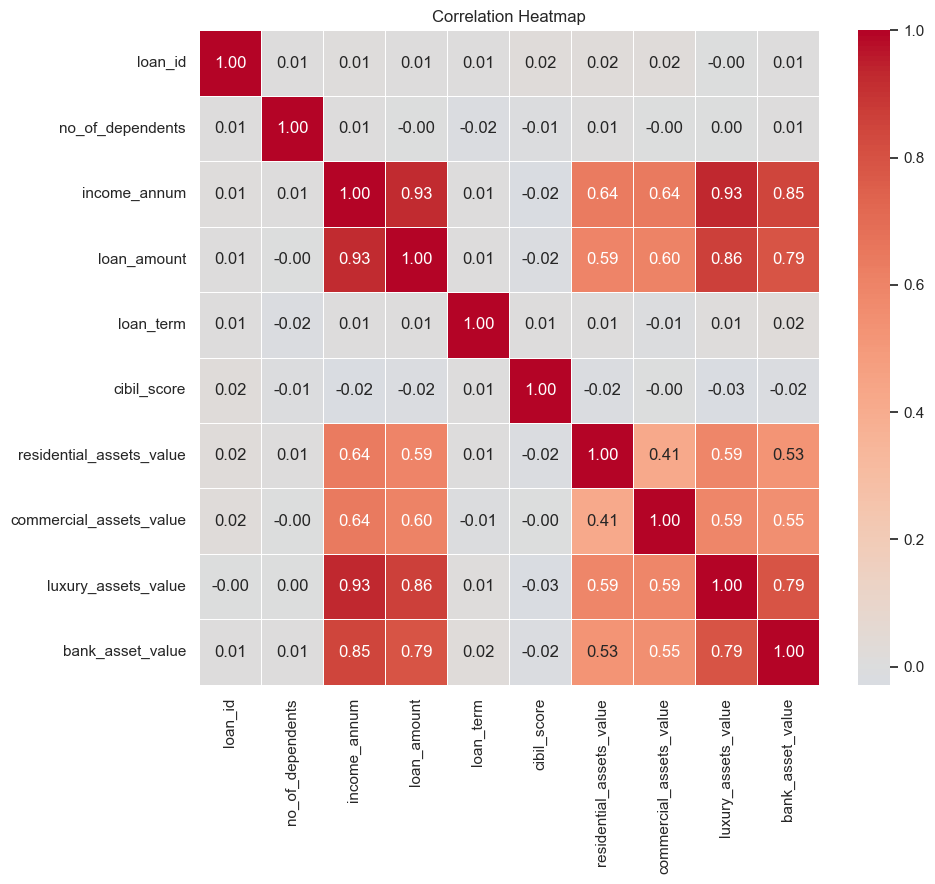

In [62]:
df_loan, target, ptype = perform_eda(
    os.path.join(DATA_DIR, 'loan_approval_dataset.csv'),
    target_column='loan_status'
)

Top 5 features (Chi-square): ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value']


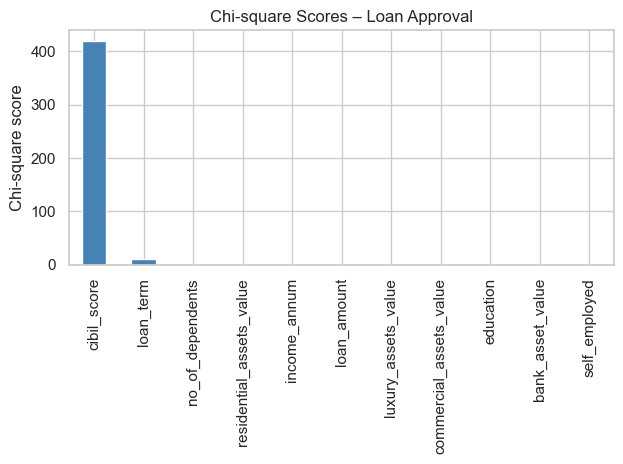

Train size: 3415  |  Test size: 854


In [ ]:
df_loan = df_loan.copy()
df_loan.drop(columns=['loan_id'], inplace=True)

le = LabelEncoder()
df_loan['education'] = le.fit_transform(df_loan['education'])
df_loan['self_employed'] = le.fit_transform(df_loan['self_employed'])
df_loan['loan_status'] = le.fit_transform(df_loan['loan_status'])   # approved=0, rejected=1

X = df_loan.drop(columns=['loan_status'])
y = df_loan['loan_status'] # target variable

X_scaled = StandardScaler().fit_transform(X)

# feature Selection 
# Chi square works here as the minimum is 0 (via MinMaxScaling)

# summation ((O-E)^2/E)
X_minmax = MinMaxScaler().fit_transform(X)
selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X_minmax, y)
selected_features = X.columns[selector.get_support()].tolist()
print('Top 5 features (Chi-square):', selected_features)

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
scores.plot(kind='bar', color='steelblue', edgecolor='white',
            title='Chi-square Scores – Loan Approval')
plt.ylabel('Chi-square score')
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2,
                                                     stratify=y, random_state=42)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train: (60000, 28, 28)  |  Test: (10000, 28, 28)
Image: 28x28 px  |  Classes: 0-9 


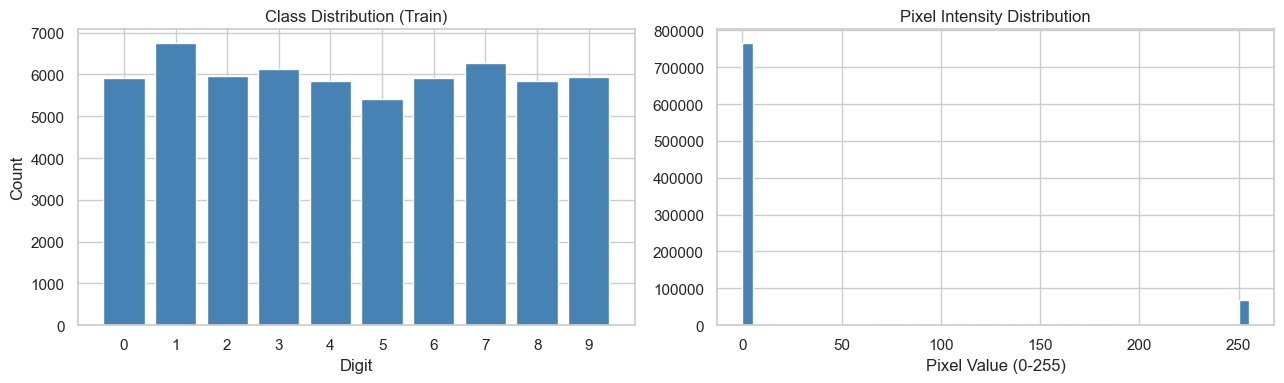

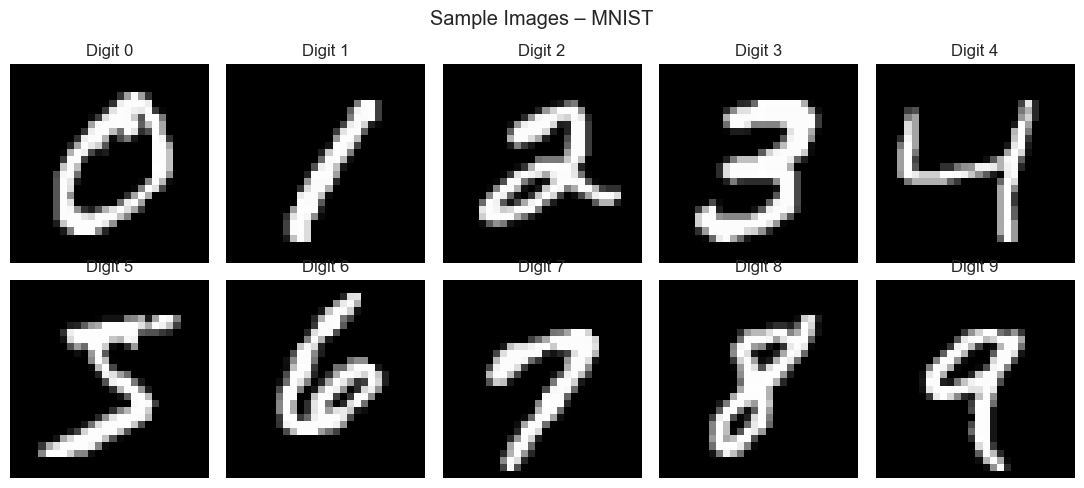

After PCA: (60000, 50)  |  Explained variance: 82.46%
Train: 45000  |  Val: 15000  |  Test: 10000
Accuracy: 0.9459

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.94      0.94      0.94      1032
           3       0.92      0.94      0.93      1010
           4       0.94      0.94      0.94       982
           5       0.94      0.93      0.93       892
           6       0.96      0.97      0.96       958
           7       0.96      0.93      0.95      1028
           8       0.92      0.91      0.92       974
           9       0.93      0.92      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



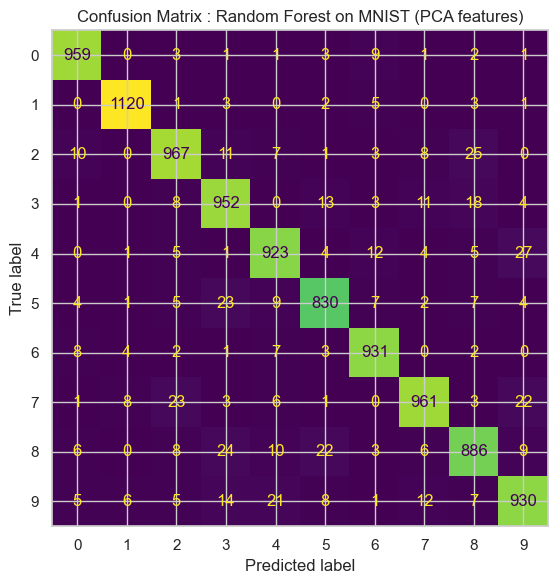

In [64]:
# loading the IDX binary files 
def load_mnist(mnist_dir):
    def read_images(path):
        with open(path, 'rb') as f:
            _, n, h, w = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, h, w)
    def read_labels(path):
        with open(path, 'rb') as f:
            _, n = struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    X_tr = read_images(os.path.join(mnist_dir, 'train-images.idx3-ubyte'))
    y_tr = read_labels(os.path.join(mnist_dir, 'train-labels.idx1-ubyte'))
    X_te = read_images(os.path.join(mnist_dir, 't10k-images.idx3-ubyte'))
    y_te = read_labels(os.path.join(mnist_dir, 't10k-labels.idx1-ubyte'))
    return X_tr, y_tr, X_te, y_te

X_train_raw, y_train_raw, X_test_raw, y_test = load_mnist(DATA_DIR)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Image: {X_train_raw.shape[1]}x{X_train_raw.shape[2]} px  |  Classes: 0-9 ')

# EDA: class distribution + pixel histogram
classes, counts = np.unique(y_train_raw, return_counts=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(classes.astype(str), counts, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution (Train)'); axes[0].set_xlabel('Digit'); axes[0].set_ylabel('Count')
axes[1].hist(X_train_raw.flatten()[::50], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Pixel Intensity Distribution'); axes[1].set_xlabel('Pixel Value (0-255)')
plt.tight_layout(); plt.savefig('figures/mnist_samples.png', format='png', dpi=600, bbox_inches='tight'); plt.show()

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit, ax in zip(range(10), axes.flatten()):
    ax.imshow(X_train_raw[np.where(y_train_raw == digit)[0][0]], cmap='gray')
    ax.set_title(f'Digit {digit}'); ax.axis('off')
plt.suptitle('Sample Images – MNIST'); plt.tight_layout(); plt.savefig('figures/mnist_samples.png', format='png', dpi=600, bbox_inches='tight'); plt.show()

# Preprocessing: flatten + normalize
X_flat_train = X_train_raw.reshape(len(X_train_raw), -1).astype(np.float32) / 255.0
X_flat_test  = X_test_raw.reshape(len(X_test_raw),  -1).astype(np.float32) / 255.0

# Feature Selection: PCA (784 → 50 principal components)
from sklearn.decomposition import PCA #PCA applied to reduce dimensionality 
pca = PCA(n_components=50, random_state=42)
X_pca_train = pca.fit_transform(X_flat_train)
X_pca_test  = pca.transform(X_flat_test)
print(f'After PCA: {X_pca_train.shape}  |  Explained variance: {pca.explained_variance_ratio_.sum():.2%}')

# Data Splitting: Train (60%) / Validation (20%) / Test (20% — pre-split by MNIST) 
X_train, X_val, y_train, y_val = train_test_split(
    X_pca_train, y_train_raw, test_size=0.25, random_state=42)
print(f'Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_pca_test.shape[0]}')

# Performance Evaluation: Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) 
y_pred = rf.predict(X_pca_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix : Random Forest on MNIST (PCA features)')
plt.tight_layout(); plt.savefig('figures/mnist_samples.png', format='png', dpi=600, bbox_inches='tight'); plt.show()


Dataset   : Handwritten Character Recognition (english.csv)
Shape     : (3410, 2)
Classes   : 62  (digits 0-9, A-Z, a-z)
Missing   : 0



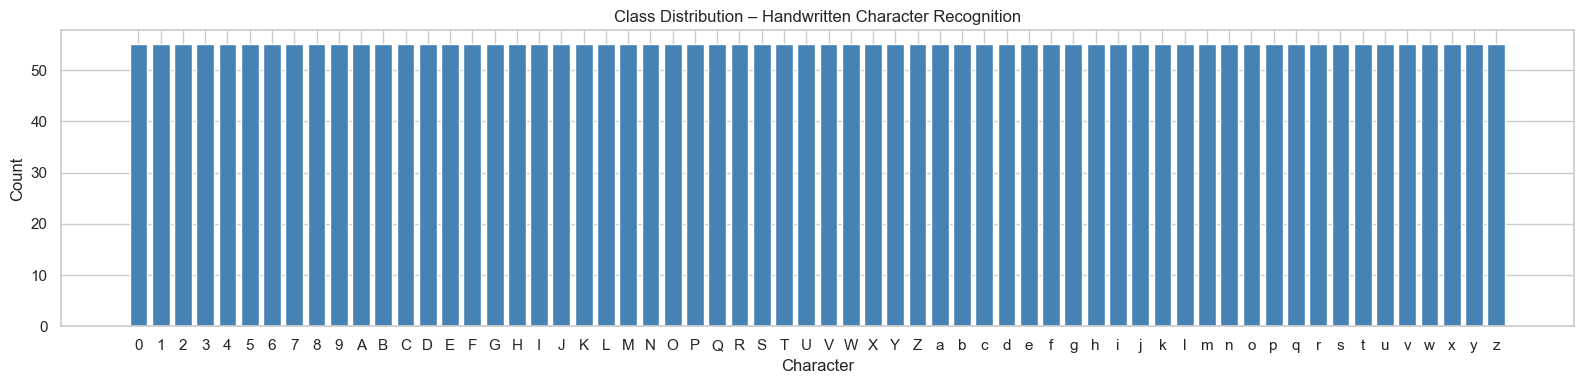

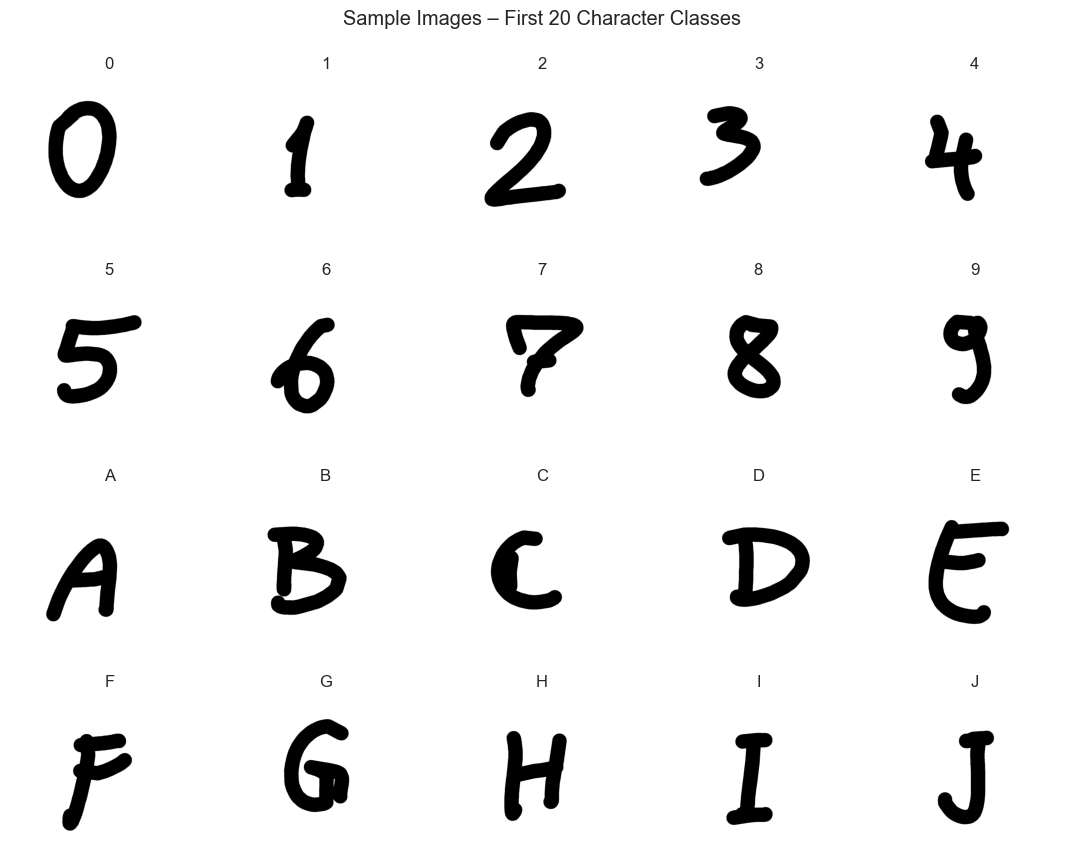

Flattened dataset shape: (3410, 784)
After PCA: (3410, 50) | Explained variance: 85.78%
Train: 2046 | Val: 682 | Test: 682
Accuracy: 0.3680

Classification Report (Top 10 classes shown for brevity):
              precision    recall  f1-score   support

           0       0.42      0.45      0.43        11
           1       0.16      0.27      0.20        11
           2       0.36      0.45      0.40        11
           3       0.56      0.45      0.50        11
           4       0.33      0.27      0.30        11
           5       0.14      0.09      0.11        11
           6       0.33      0.18      0.24        11
           7       0.47      0.64      0.54        11
           8       0.86      0.55      0.67        11
           9       0.42      0.45      0.43        11

   micro avg       0.38      0.38      0.38       110
   macro avg       0.40      0.38      0.38       110
weighted avg       0.40      0.38      0.38       110



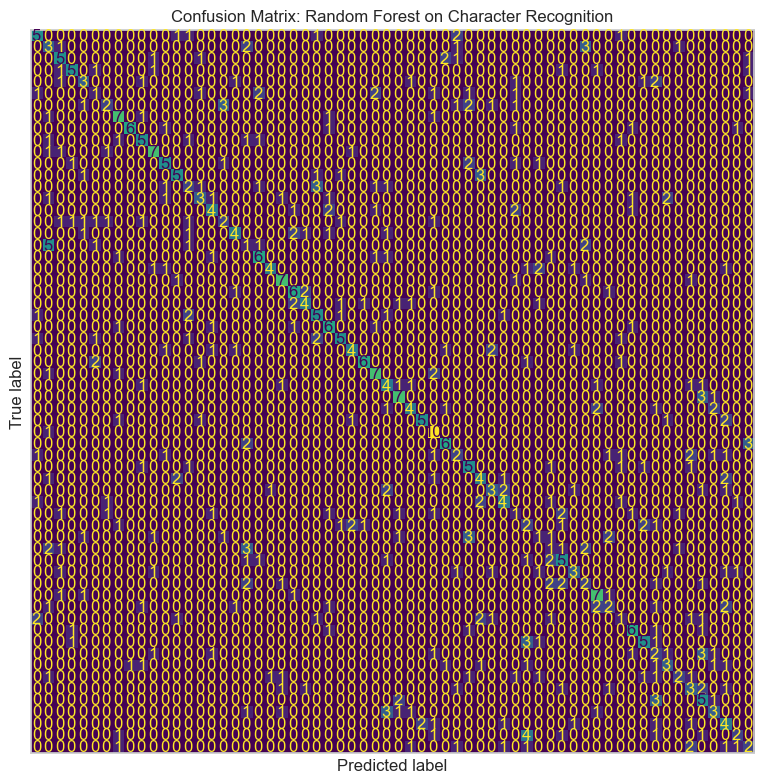

In [65]:
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

df_char = pd.read_csv(os.path.join(DATA_DIR, 'english.csv'))
df_char.columns = df_char.columns.str.strip()

print('Dataset   : Handwritten Character Recognition (english.csv)')
print(f'Shape     : {df_char.shape}')
print(f'Classes   : {df_char["label"].nunique()}  (digits 0-9, A-Z, a-z)')
print(f'Missing   : {df_char.isnull().sum().sum()}')
print()

# Class distribution
vc = df_char['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution – Handwritten Character Recognition')
ax.set_xlabel('Character'); ax.set_ylabel('Count')
plt.tight_layout(); plt.savefig('figures/char_confusion.png', format='png', dpi=600, bbox_inches='tight'); plt.show()

# Sample images (one per class, first 20 classes)
sample_labels = sorted(df_char['label'].unique())[:20]
fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for ax, lbl in zip(axes.flatten(), sample_labels):
    img_path = os.path.join(DATA_DIR, df_char[df_char['label'] == lbl]['image'].iloc[0])
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(str(lbl)); ax.axis('off')
plt.suptitle('Sample Images – First 20 Character Classes')
plt.tight_layout(); plt.savefig('figures/char_confusion.png', format='png', dpi=600, bbox_inches='tight'); plt.show()

# Preprocessing: Load, resize to 28x28, flatten, normalize
images = []
labels = []
label_encoder = LabelEncoder()

# Process images efficiently
for idx, row in df_char.iterrows():
    img_path = os.path.join(DATA_DIR, row['image'])
    img = Image.open(img_path).convert('L')
    img = img.resize((28, 28)) # standardize size
    img_array = np.array(img).flatten().astype(np.float32) / 255.0
    images.append(img_array)
    labels.append(row['label'])

X = np.array(images)
y = label_encoder.fit_transform(labels)
print(f'Flattened dataset shape: {X.shape}')

# Feature Selection: PCA (reduced to 50 components)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f'After PCA: {X_pca.shape} | Explained variance: {pca.explained_variance_ratio_.sum():.2%}')

# Data Splitting: Train (60%) / Val (20%) / Test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42)
print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Performance Evaluation: Random Forest
rf_char = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_char.fit(X_train, y_train)
y_pred = rf_char.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report (Top 10 classes shown for brevity):')
# Print classification report for the first 10 classes
print(classification_report(y_test, y_pred, labels=range(10), target_names=label_encoder.inverse_transform(range(10))))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix: Random Forest on Character Recognition')

ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig('figures/char_confusion.png', format='png', dpi=600, bbox_inches='tight'); plt.show()
